# 单细胞分析 | Seurat基础流程 | 保姆级教程

Seurat的分析是从单细胞计数矩阵开始的。单细胞计数矩阵是由  `cellranger`流程对下机数据进行处理而产生的，里面存储的是UMI计数矩阵，矩阵中的值表示的是在每个细胞（列）中检测到的每个特征（即基因，行）的分子数。



In [24]:
# 加载分析所需要的包
library(dplyr)
library(Seurat)
library(patchwork)

In [25]:

setwd("/Users/a1-6/Documents/projects/DL/97-bioinformatics/gene_process_for_python/single-cell-rna")
####清除环境，就是把环境清空了
rm(list=ls())

## 创建Seurat对象
Seurat的对象将作为一个容器，其中包含单细胞数据集的数据和分析的结果。


### 加载数据集
首先，需要加载我们的数据集：

In [26]:
##读取10x的数据
scRNA.counts=Read10X("data/GSE152048_BC21.matrix/BC21")
class(scRNA.counts)

[1] "dgCMatrix"
attr(,"package")
[1] "Matrix"

## 数据集文件解析
测试数据集中包含`barcodes.tsv`、`genes.tsv`、`matrix.mtx`三个文件。

在解释三个文件之前，我们先统计一下这三个文件的行数，一会儿有用哟！


```bash
$ wc -l *
2700 barcodes.tsv
32738 genes.tsv
2286887 matrix.mtx
2322325 total

```



接下来，我们开始解析每个文件：      
1.`barcodes.tsv`文件存储的是用于标记不同细胞的条形码序列，即barcode，只有一列信息，由于其标记的是细胞，所以该文件的行数对应的就是细胞数量，由行数统计结果可知细胞数量为`2700`个；           
```bash 
$ head barcodes.tsv    
AAACATACAACCAC-1          
AAACATTGAGCTAC-1         
AAACATTGATCAGC-1         
AAACCGTGCTTCCG-1        
AAACCGTGTATGCG-1  

```

2.`genes.tsv`文件存储的是基因的信息，分别为`gene id`（第一列）和`gene symbol`（第二列），列数不固定，主要作为矩阵的行名，可进行匹配识别基因即可。与`barcodes.tsv`文件同理，该文件的行数对应的是基因数量，基因数量为32738个；            
```bash
$ head genes.tsv          
ENSG00000243485 MIR1302-10  
ENSG00000237613 FAM138A
ENSG00000186092 OR4F5
ENSG00000238009 RP11-34P13.7
ENSG00000239945 RP11-34P13.8
```

3.`matrix.mtx`文件存储的主要是有表达量的基因的counts数量（第三列信息，即表达量信息），前三行为`注释信息`，其中第三行跟我们上面统计的每个文件的行数信息基本对应，实际上这三个数字对应的便分别是`基因数量`、`细胞数量`、`有表达量的基因的数量`（任一基因在任一细胞中出现都算一次计数），去掉三行注释行，刚好是2286884行。
```bash
$ head matrix.mtx
%%MatrixMarket matrix coordinate real general
%
32738 2700 2286884
32709 1 4
32707 1 1
32706 1 10
32704 1 1
32703 1 5
32702 1 6
32700 1 10
```

我看别人说，这种方式可以高效地存储数据。我们随便找一行举例，看看这个文件怎么解析啊。比如"32706 1 10"这一行，表示的是`barcodes.tsv`文件中的第1个细胞的在`genes.tsv`文件中的第`32706`个基因的`counts`数为10。

## 创建Seurat对象
接下来，我们就来创建一个Seurat对象：


In [27]:
# 创建Seurat对象
pbmc <- CreateSeuratObject(scRNA.counts , 
                           min.cells = 3, 
                           project="os", 
                           min.features = 300)
pbmc
#查看对象信息

An object of class Seurat 
20288 features across 6342 samples within 1 assay 
Active assay: RNA (20288 features, 0 variable features)
 1 layer present: counts

CreateSeuratObject的几个主要参数：

- counts：输入对应的矩阵信息
- project：Seurat对象的项目名
- min.cells：规定基因的表达范围，即单个基因至少在多少个细胞中表达方可保留
- min.features：规定细胞表达的基因数范围，即单个细胞中至少表达多少个基因方可保留


In [28]:
# 创建Seurat对象，不加过滤条件
pbmc <- CreateSeuratObject(counts = scRNA.counts)
pbmc

An object of class Seurat 
32864 features across 6580 samples within 1 assay 
Active assay: RNA (32864 features, 0 variable features)
 1 layer present: counts

我们可以看到数据集变成了一个2700个细胞，13714个基因的矩阵，说明上面过滤掉了一部分基因的信息，细胞的表达的基因数量都高于过滤阈值，所以细胞数量并没有减少。   
    
我们也可以简单看一下不加这些参数会是什么样！  

In [29]:
# 我们参照官网示例，看看部分基因在前30个细胞中的表达矩阵信息。
# 三个基因：CD3D、TCL1A、MS4A1在前30个细胞中的表达矩阵信息
scRNA.counts[c("CD3D", "TCL1A", "MS4A1"), 1:30]


  [[ suppressing 30 column names 'AAACCCAAGAGATGCC-1', 'AAACCCAAGCCTCTCT-1', 'AAACCCAAGCGCTTCG-1' ... ]]



3 x 30 sparse Matrix of class "dgCMatrix"
                                                                 
CD3D  6 . . . . . . . . . . . . . 2 2 1 . . . . . . 2 . . . . . .
TCL1A . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
MS4A1 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

.在矩阵中代表0，表示未在该细胞中检测到该基因。


为什么要用`.`来代表0呢？
这是由于scRNA-seq矩阵中的大多数值都是0，0属于无效信息，存储他们的值和位置信息需要占用大量内存，而Seurat尽可能使用稀疏矩阵表示，只需要存储非0数据的值和位置信息，因此，这将大大节省计算数据的内存和速度。

这样讲太笼统了，我们直接上数据：

In [30]:
# 密集矩阵
dense.size <- object.size(as.matrix(scRNA.counts))
dense.size
# 1732759248 bytes

Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 1.6 GiB"


1732759248 bytes

In [31]:
# 稀疏矩阵
sparse.size <- object.size(scRNA.counts)
sparse.size
# 183391128 bytes

183391128 bytes

In [32]:
# 两者相差倍数
dense.size/sparse.size
# 23.7 bytes

9.4 bytes

可以看到使用稀疏矩阵存储数据可以极大的减少数据的内存占用（23.7倍），提升运行的速度。

## 02 标准预处理工作流程

该步骤主要是进行质控以及选择细胞进行进一步分析。

Seurat中一些常用的质控（QC）指标：

`nFeature_RNA`：每个细胞中检测到的基因的数量。
- 低质量的细胞或空液滴通常含有很少的基因；
- 细胞双胞体或多胞体可能表现出异常高的基因计数。

`nCount_RNA`：细胞内检测到的分子总数。即检测到的基因的总数量（一个基因可能会因为有多个转录本而被检测到多次），因此分子总数与基因数量密切相关。

`percent.mt`：对应线粒体基因组的序列的百分比。低质量/濒死的细胞通常表现出广泛的线粒体污染。我们通常使用PercentageFeatureSet()函数来计算线粒体基因相关的reads的百分比。代码如下：

In [33]:
pbmc[["percent.mt"]] <- PercentageFeatureSet(pbmc, pattern = "^MT-")

`"[[]]"`运算符可以向对象pbmc的元数据`meta.data`中添加列。`meta.data`是一个存储QC统计数据的好地方。关于`seurat V4`的数据结构以及和V5版本数据结构的区别后续会做讲解。

我们先来看一下计算这一步之前的meta.data长什么样子：

In [34]:
head(pbmc@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt
,<fct>,<dbl>,<int>,<dbl>
AAACCCAAGAGATGCC-1,SeuratProject,2570,954,5.019455
AAACCCAAGCCTCTCT-1,SeuratProject,1215,691,6.913580
AAACCCAAGCGCTTCG-1,SeuratProject,10490,3512,7.197331
AAACCCACACGCAAAG-1,SeuratProject,1070,177,80.000000
AAACCCAGTCACTCGG-1,SeuratProject,15726,3973,3.821697
AAACCCAGTGGCTAGA-1,SeuratProject,7569,1616,16.633637


这里可能有人会问，这里面的信息除了第一列`orig.ident`好像是在`CreateSeuratObject()`的时候定义的`project`，后面两个参数`nCount_RNA`和`nFeature_RNA`是哪来的呢？这是由于在`CreateSeuratObject()`过程中会自动计算基因的数量`nFeature_RNA`和分子总数`nCount_RNA`，他们会被存储在对象的`meta.data`中。

我们再来看一下计算这一步之后的`meta.data`：

In [35]:
# 计算后的meta.data
pbmc[["percent.mt"]] <- PercentageFeatureSet(pbmc, pattern = "^MT-")
head(pbmc@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt
,<fct>,<dbl>,<int>,<dbl>
AAACCCAAGAGATGCC-1,SeuratProject,2570,954,5.019455
AAACCCAAGCCTCTCT-1,SeuratProject,1215,691,6.913580
AAACCCAAGCGCTTCG-1,SeuratProject,10490,3512,7.197331
AAACCCACACGCAAAG-1,SeuratProject,1070,177,80.000000
AAACCCAGTCACTCGG-1,SeuratProject,15726,3973,3.821697
AAACCCAGTGGCTAGA-1,SeuratProject,7569,1616,16.633637


多了这样一列 percent.mt的数据，存储的便是每个细胞中线粒体基因的占比情况。

注：上面是作为示例数据，他的基因格式比较标准。

本教程中的线粒体基因如下：

In [36]:
rownames(pbmc)[grep("^MT-", rownames(pbmc))]

[1] "MT-ND1"  "MT-ND2"  "MT-CO1"  "MT-CO2"  "MT-ATP8" "MT-ATP6" "MT-CO3" 
 [8] "MT-ND3"  "MT-ND4L" "MT-ND4"  "MT-ND5"  "MT-ND6"  "MT-CYB"

那么当我们使用常规的数据，只知道线粒体基因的id，他们没有共同特征时该怎么办呢？方法就是把pattern展开来写，只有13个基因，稍微费点事就写下来了：

In [37]:
pbmc[["percent.mt"]] <- PercentageFeatureSet(pbmc, 
                                             pattern = "ATP6|ATP8|COX1|COX2|COX3|CYTB|ND1|ND2|ND3|ND4|ND4L|ND5|ND6")

那还有人会问了，如果不知道线粒体基因的信息怎么办呢？这个线粒体基因信息在gtf或者gff文件中都会有的，你去找一下基本都会找到的，找到后再像上面一样匹配就好啦！

上面我们介绍完质控的这些指标，那么就进入正题，开始质控吧！


#### 设置阈值
首先呢，我们要了解如何设置质控指标的阈值。

质控的目的是挑选质量更好的细胞进行进一步的分析，那么我们如何有针对性地进行挑选呢？当然是需要在质控前先对质控的指标进行一波统计，作为设置阈值的参考。统计的方法很简单，小提琴图VlnPlot和散点图FeatureScatter （VlnPlot这个函数有很多的功能，这里就先略过，下次专门整理！），我们就按照官网上的来：

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


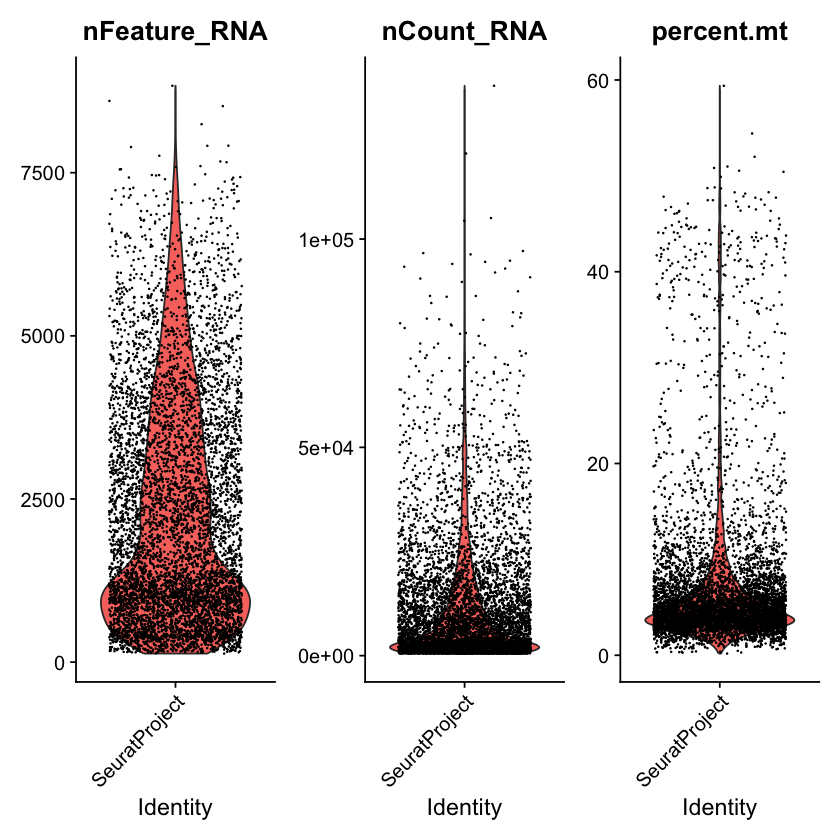

In [38]:
# 使用小提琴图可视化QC指标
VlnPlot(pbmc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

第一个图nFeature_RNA是对所有细胞检测到的基因数量的小提琴图，横坐标为样品名，纵坐标为每个细胞中包含的基因数量，图中的每个点代表一个细胞；

第二个图nCount_RNA为样品所有细胞内检测到的分子总数的小提琴图，横坐标为样品名，纵坐标为每个细胞内检测到的分子总数，图中的每个点代表一个细胞。

第三个图percent.mt为样品所有细胞的线粒体基因比例的小提琴图，横坐标为样品名，纵坐标为每个细胞的线粒体基因比例，图中的每个点代表一个细胞。

小提琴图展示了任意位置数值的密度，可以知道哪些位置的数值的密度较高。

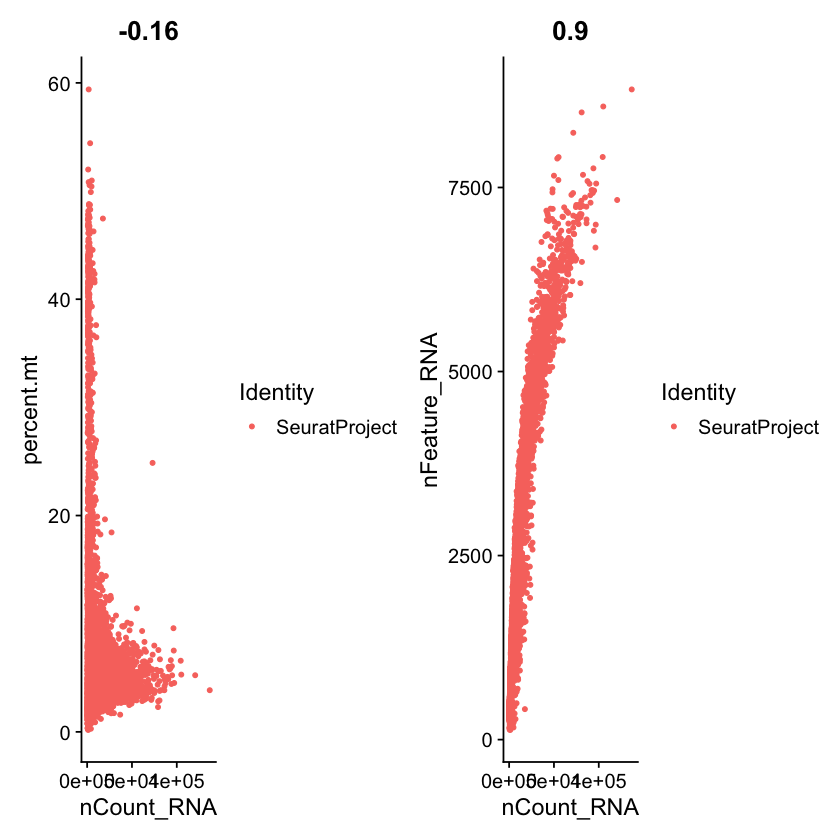

In [39]:
# FeatureScatter是一种典型的可视化特征与特征之间关系的方法
plot1 <- FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

随着测序深度的增加，单细胞所检测到的基因数量也在增加，两者是有一定关联性的。

对含有线粒体基因的细胞进行筛选是因为线粒体基因比例过高的细胞通常为低质量的细胞，这些数据杂糅进来会干扰细胞分群。

第一个图`nCount_RNA vs percent.mt`，是线粒体基因比例与细胞中检测到的分子总数的关系的散点图，通常两者没有什么相关关系，我们通常对这两个指标的标准是：线粒体基因比例应相对较低以排除低质量/濒死的细胞，细胞中检测到的分子总数也不宜过高以排除双胞和多胞细胞的影响。

第二个图`nCount_RNA vs nFeature_RNA`，是基因数量与细胞中检测到的分子总数的关系的散点图，即测序深度与基因数量的关系。高质量的测序数据中两者基本处于正相关的关系，但要排除由于双胞和多胞造成的分子数量过大的部分数据，即右上方离群点。



开始过滤
接着呢，我们就开始过滤！

根据小提琴图和散点图的情况，个人认为可以选择如下的质控过滤指标，即：

- nFeature_RNA > 200（最开始的min.features = 200）& nFeature_RNA < 2000
- nCount_RNA < 7000
- percent.mt < 7

但是呢，为了和官方教程相统一，我们还是采用官方的过滤阈值，实际上相差并不多!

In [40]:
pbmc <- subset(pbmc, subset = nFeature_RNA > 200 & nFeature_RNA < 2500 & percent.mt < 5)

过滤完成     
最后，过滤完成，让我们检查一些指标看看吧！

In [ ]:
# 细胞数量
pbmc


An object of class Seurat 
32864 features across 1943 samples within 1 assay 
Active assay: RNA (32864 features, 0 variable features)
 1 layer present: counts

可以看到这一通简单的过滤之后，细胞数量减少到了1943，基因数量不变。

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


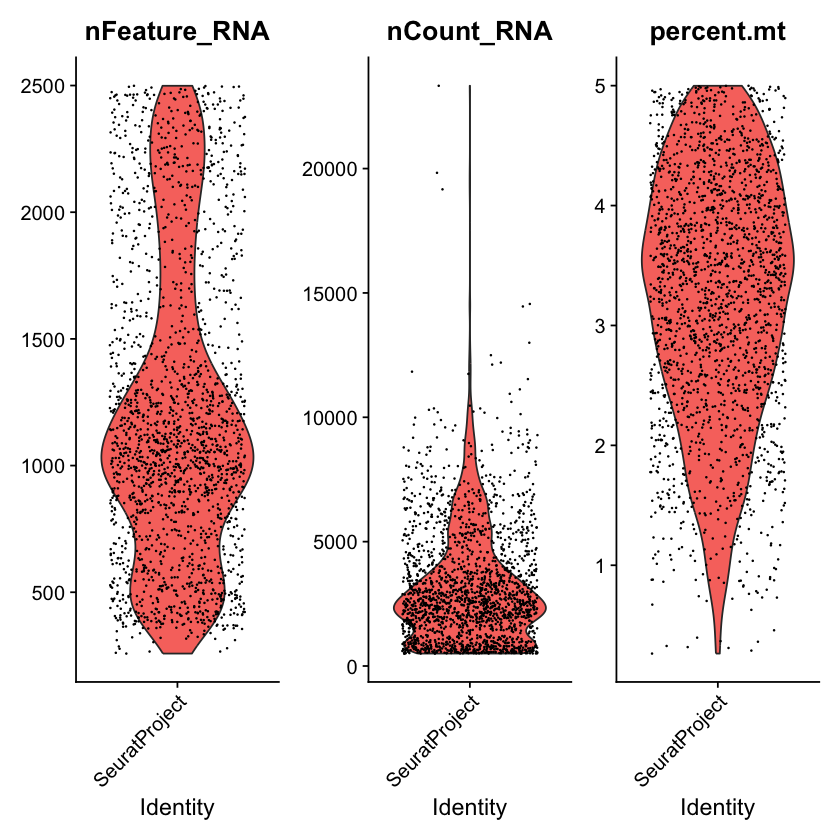

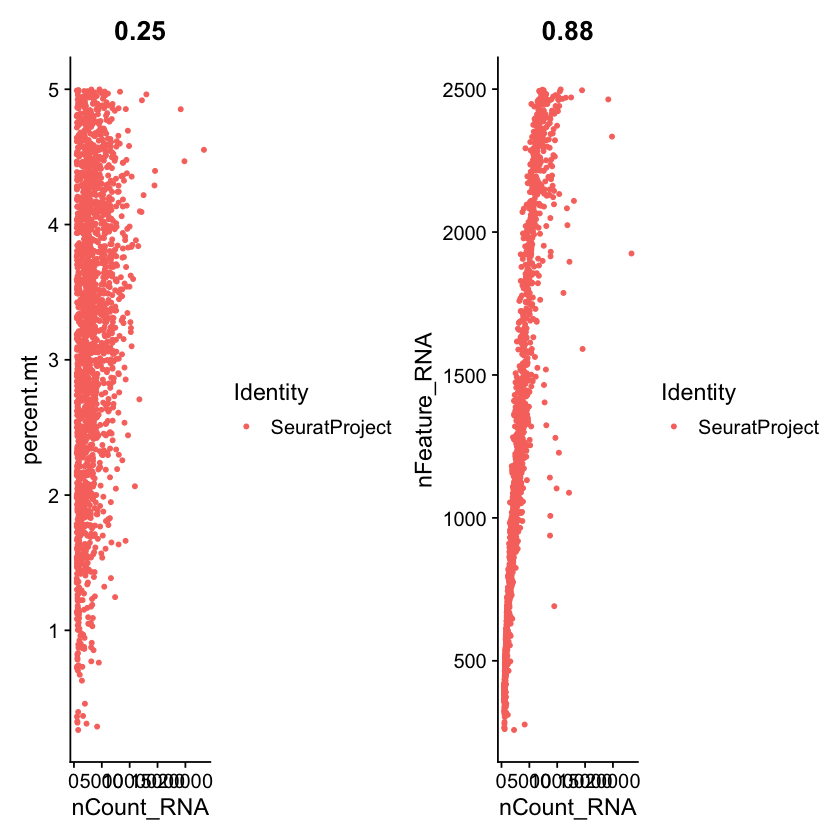

In [42]:
# 小提琴图可视化QC指标
VlnPlot(pbmc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
# FeatureScatter可视化QC指标之间的关系
plot1 <- FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

03 数据标准化
通过质控过滤完不需要的细胞之后呢，就要对数据进行标准化处理了！   

LogNormalize：全局缩放的标准化方法（其实还有另一种标准化方法SCTransform，随后咱单独整理一篇！）    

为什么要做normalization呢？
因为细胞间的异质性除了可能来自于细胞自身基因的差异表达，还有可能是由测序技术误差造成的。数据标准化的目的便是排除技术误差，让测序深度和文库大小不同的细胞的基因表达量具有可比性，进而更好地呈现基因水平的差异。    

计算方法     
we employ a global-scaling normalization method “LogNormalize” that normalizes the feature expression measurements for each cell by the total expression, multiplies this by a scale factor (10,000 by default), and log-transforms the result.      
我们直接上公式，这个简单易懂，其中的log1p指的是log(x + 1)，只看到log就表示以e为底的log值。   
Value：该基因在该细胞中的表达量

<img src="https://pic4.zhimg.com/v2-17018c37ff9e43818dcc891a3659fddd_1440w.jpg">

In [ ]:
# 执行代码
# scale.factor这里我们选择10000
pbmc <- NormalizeData(pbmc, 
                      normalization.method = "LogNormalize", 
                      scale.factor = 10000)
# 结果储存在pbmc[["RNA"]]@data中，可以通过pbmc[["RNA"]]@data查看
head(pbmc@assays$RNA@layers$counts[1:, 1:25])
head(pbmc@assays$RNA@layers$data[1:6, 1:25])



Normalizing layer: counts



6 x 25 sparse Matrix of class "dgCMatrix"
                                                      
[1,] . . . . . . . . . . . . . . . . . . . . . . . . .
[2,] . . . . . . . . . . . . . . . . . . . . . . . . .
[3,] . . . . . . . . . . . . . . . . . . . . . . . . .
[4,] . . . . . . . . . . . . . . . . . . . . . . . . .
[5,] . . . . . . . . . . . . . . . . . . . . . . . . .
[6,] . . . . . . . . . . . . . . . . . . . . . . . . .

6 x 25 sparse Matrix of class "dgCMatrix"
                                                      
[1,] . . . . . . . . . . . . . . . . . . . . . . . . .
[2,] . . . . . . . . . . . . . . . . . . . . . . . . .
[3,] . . . . . . . . . . . . . . . . . . . . . . . . .
[4,] . . . . . . . . . . . . . . . . . . . . . . . . .
[5,] . . . . . . . . . . . . . . . . . . . . . . . . .
[6,] . . . . . . . . . . . . . . . . . . . . . . . . .

那么，问题来了，为什么原始数据都是1，在标准化之后数值就不一样了呢？原因很简单，因为不同细胞的总counts（即all_gene_counts）发生了改变，导致最终的值发生了改变。

## 04 鉴定高可变基因
我们接下来计算在数据集中表现出细胞间高差异性的基因子集（即它们在一些细胞中高度表达，在另一些细胞中低度表达）。研究发现，在下游分析中这些基因有助于突出单细胞数据集中的生物信号。

FindVariableFeatures：鉴定高可变基因的函数，默认返回每个数据集的前2000个基因用于像PCA这样的下游分析。这一部分没啥好说的，后面分析就主要用这2000个基因了，这样可以减小内存和计算资源。

In [49]:
# FindVariableFeatures鉴定高可变基因
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 2000)

Finding variable features for layer counts



In [50]:
# 鉴定10个最高变的基因
top10 <- head(VariableFeatures(pbmc), 10)

When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."


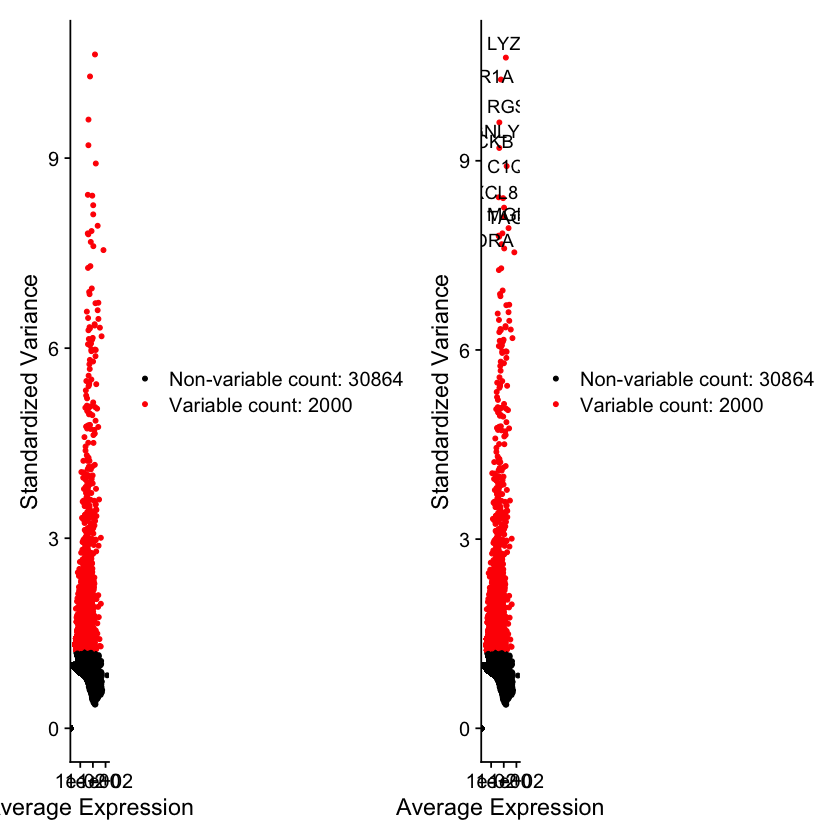

In [51]:
# 绘制高可变基因的火山图
plot1 <- VariableFeaturePlot(pbmc)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot1 + plot2

## 05 数据缩放（数据中心化）
在计算完高可变基因后，需要对数据集进行一个线性转换（缩放）。

这个步骤是降维（如PCA）数据处理之前的一个标准的预处理过程，由ScaleData()这个函数执行。该函数的作用解析如下：

- 调整每个基因的表达量，使得细胞间的平均表达量为0
- 缩放每个基因的表达量，使得细胞间的方差为1
- 目的：这一步骤赋予每个基因在下游分析中同样的权重，不至于使高表达基因占据主导地位
- 结果存储在pbmc[["RNA"]]$scale.data中

运行代码如下：

In [52]:
# 将Seurat对象的行名（所有基因）抓取出来
all.genes <- rownames(pbmc)
# 以基因为单位对矩阵数据进行缩放
pbmc <- ScaleData(pbmc, features = all.genes)

Centering and scaling data matrix



总结：概括起来讲，scale的作用是使数据具有一个统一的尺度，这并不会影响每个点的相对位置，只是使他们的表达量尺度统一起来。是PCA分析的必要步骤。

官网关于这一步讨论了两个问题：

第一个问题是这一步的运行时间太长，是否可以加速运行？答案是肯定的。首先我们要明确的一点是虽然缩放是Seurat分析过程中不可缺少的一步，但是也只是需要将PCA分析需要的基因作为输入即可，因此，在这一点上ScaleData()默认使用的是先前鉴定的2000个高变基因。所以将features参数去掉，将all.genes变成高变基因即可减少运行时间。pbmc <- ScaleData(pbmc)
#### 也可以这样运行
```R
scale.genes <- VariableFeatures(pbmc)
pbmc <- ScaleData(pbmc, features = scale.genes)
```
第二个问题是如何删除不需要的变异来源？
```R
pbmc <- ScaleData(pbmc, vars.to.regress = "percent.mt")
```
#### 如果希望使用此功能，建议使用新的标准化方法SCTransform()
#### 关于这个问题，我的了解较少，在此处不做过多展开。

## 06 PCA线性降维
PCA分析    
接下来，对缩放的数据进行PCA分析。   

通常情况下，使用上述计算的高变基因进行PCA分析，基因集的选择可以通过features参数进行设置。  

In [53]:
pbmc <- RunPCA(pbmc, features = VariableFeatures(pbmc))

PC_ 1 
Positive:  DUSP1, HLA-DRB1, FOS, CD69, GZMK, S100A4, CD74, HLA-DPA1, IER5, KLRB1 
	   TNFAIP3, DUSP2, HLA-DQA1, GPR183, COTL1, IL7R, HSPA1A, ATP2B1-AS1, CCL4, TMSB10 
	   NFKBIA, HSPA6, LINC01871, RGS2, HSPH1, HMGB2, GADD45B, HLA-DMA, CTSS, HIST1H1D 
Negative:  FBLN1, SSPN, PCOLCE, LRP1, SPARC, COL1A1, COL5A2, MMP2, HTRA1, BHLHE41 
	   OMD, COL5A1, OGN, PMEPA1, BGN, FSTL1, COL8A1, C1S, VCAN, MFAP2 
	   OS9, FGFR1, SDC2, FNDC1, PRRX1, PPFIBP1, TSPAN31, CFH, COL6A2, FRS2 
PC_ 2 
Positive:  CLEC14A, CDH5, ESAM, SPARCL1, FLT1, CD34, VWF, BCAM, SOX18, CAV1 
	   RAMP2, ADGRL4, COL4A1, ARHGAP29, IFI27, ADGRF5, COL4A2, NPDC1, GNG11, PTPRB 
	   ITGA6, CALCRL, ROBO4, PREX2, CLDN5, BTNL9, PALMD, TM4SF1, IGFBP7, TSHZ2 
Negative:  S100A4, SSPN, FBLN1, LRP1, COL1A1, BHLHE41, FNDC1, OMD, COL8A1, PCOLCE 
	   FRS2, OGN, MFAP2, CCND2, PLEKHA5, SERPINF1, COL8A2, COL5A2, TSPAN31, CCT2 
	   LGALS1, SDC2, THBS2, PDGFRL, VCAN, CD69, C1S, GZMK, SLC35E3, DSEL 
PC_ 3 
Positive:  FCER1G, AIF1, CD14, TYROB

接下来进行PCA结果的可视化（其实不太重要）。

Seurat提供了几种方法来对PCA结果的细胞和基因进行可视化，包括VizDimReduce()、 DimPlot()和DimHeatmap()。

第一种：VizDimLoadings()：VizDimLoadings是一个R包中的函数，用于绘制维度加载图。维度加载图是一种用于可视化主成分分析（PCA）或其他降维方法中的变量与主成分之间的关系的图形。它显示了每个变量在每个主成分上的贡献程度，可以帮助我们理解变量在不同主成分上的权重和相关性。这种图形通常以散点图或箭头图的形式呈现。

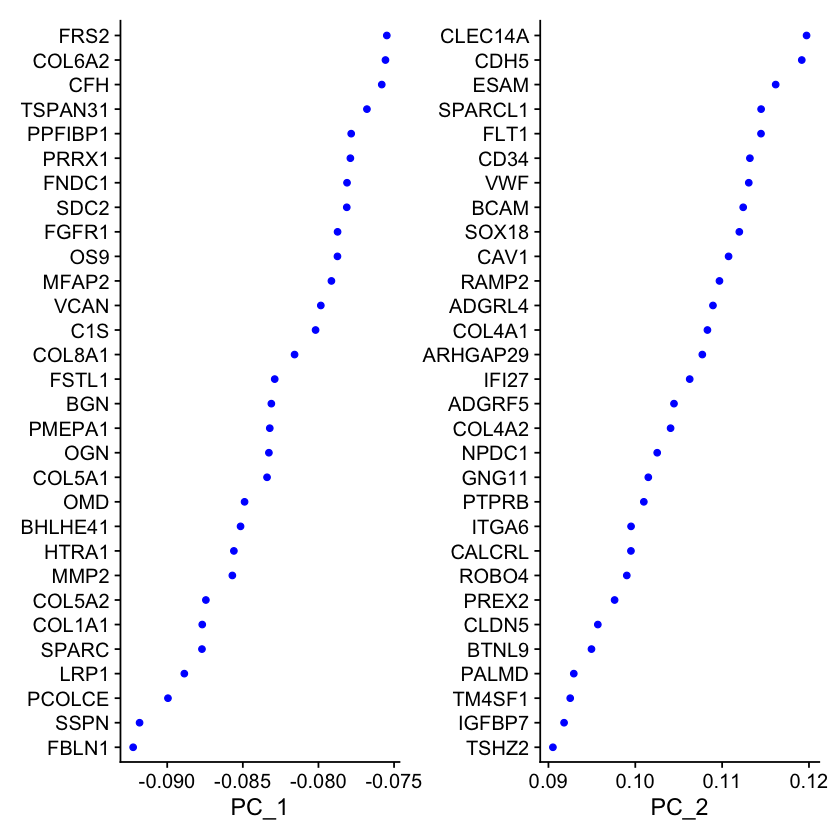

In [54]:
# 绘制前两个主成分，降维方式采用pca方法。
VizDimLoadings(pbmc, dims = 1:2, reduction = "pca") # 没啥用其实

第二种：DimPlot()：DimPlot函数可以将单细胞数据降维后的结果可视化，以便于我们观察不同细胞之间的相似性和差异性。在散点图中，每个点代表一个单细胞，不同颜色或形状的点表示不同的细胞类型或状态。通过观察散点图，我们可以发现细胞之间的聚类模式、相似性和差异性，进而对细胞类型或状态进行分类和注释。此外，DimPlot函数还可以根据其他降维方法（如t-SNE和UMAP）进行可视化，以便于我们比较不同降维方法的效果。

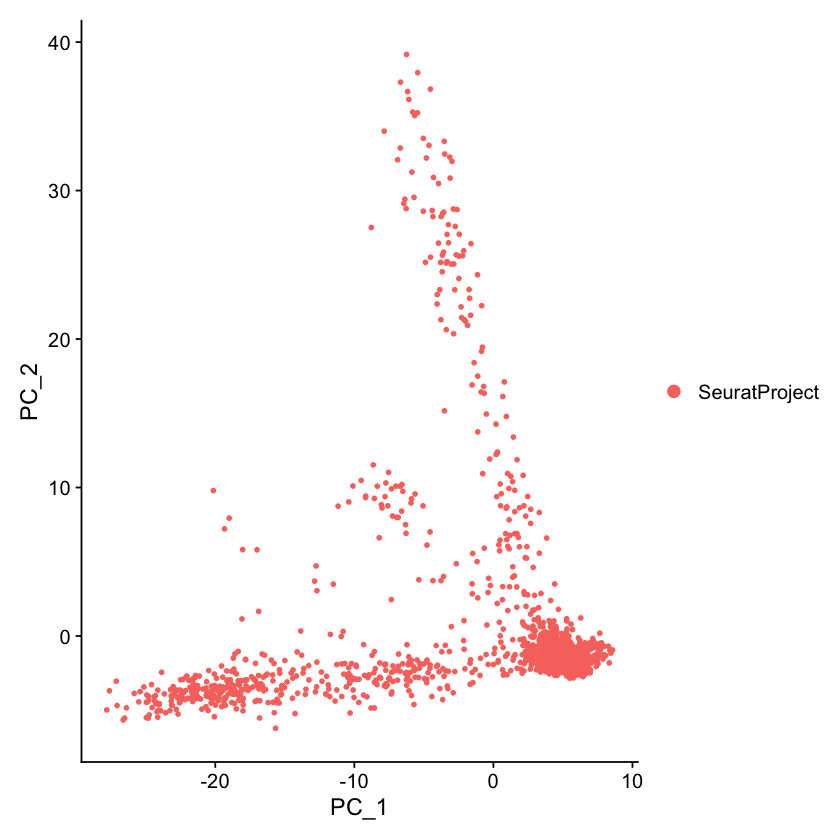

In [55]:
DimPlot(pbmc, reduction = "pca") # 也没啥用，但是分析基本都会展示一下

第三种：DimHeatmap()：DimHeatmap函数可以将单细胞数据在降维空间中的表达模式可视化，以便于我们观察不同基因或基因集之间的表达模式和差异性。在热图中，每一列代表一个细胞，每一行代表一个基因或基因集，颜色的深浅表示该基因或基因集在该细胞中的表达水平。通过观察热图，我们可以发现不同基因或基因集之间的相关性、表达模式和差异性，进而对细胞类型或状态进行分类和注释。在DimHeatmap函数中，我们可以指定降维的主成分数量和用于绘制热图的细胞数量，以便于我们控制可视化结果的精度和速度。此外，如果存在批次效应或其他技术因素导致的表达偏差，可以使用平衡化方法来消除这些效应，从而提高可视化结果的准确性和可靠性。

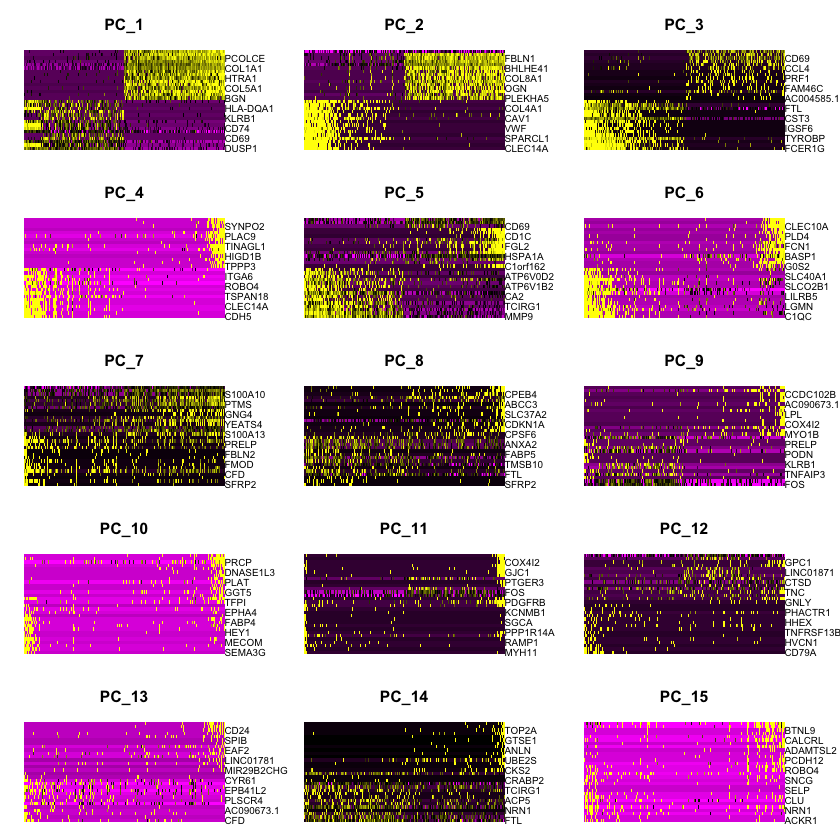

In [56]:
DimHeatmap(pbmc, dims = 1:15, cells = 500, balanced = TRUE) # 也没啥用

## 07 确定后续分析需要的“维度”
为了克服scRNA-seq数据的任何单一基因的广泛技术噪音，Seurat基于PCA分数对细胞进行聚类，每个PC基本上代表一个“metafeature”（metafeature可以理解为一组基因，这群基因具有相似的表达pattern），因此，数据集的前几个主成分被稳定（robust）地压缩（上面这一句是官网翻译过来的，Robust：稳健的，音译为鲁棒性，鲁棒性是指在面对异常情况或噪声时，系统或方法仍能保持稳定和可靠的能力。在数据分析中，鲁棒性通常指的是某个统计模型或算法对于数据中的离群点、缺失值、错误值等异常情况的容忍度。具有较高鲁棒性的模型或算法能够有效地识别和处理异常值，从而提高分析结果的准确性和可靠性）。因此，如何准确地确定降维的“维度”对后续的分析非常重要！

通常情况下，我们使用最多的就是肘形图（ElbowPlot），原因很简单，就是结果展现形式很直观（在V4官网上还有一种JackStraw图，肘形图实际上也来源于这种图，只不过JackStraw图并不直观，个人感觉在实际操作中也很少人用，这里就不做阐述啦）。



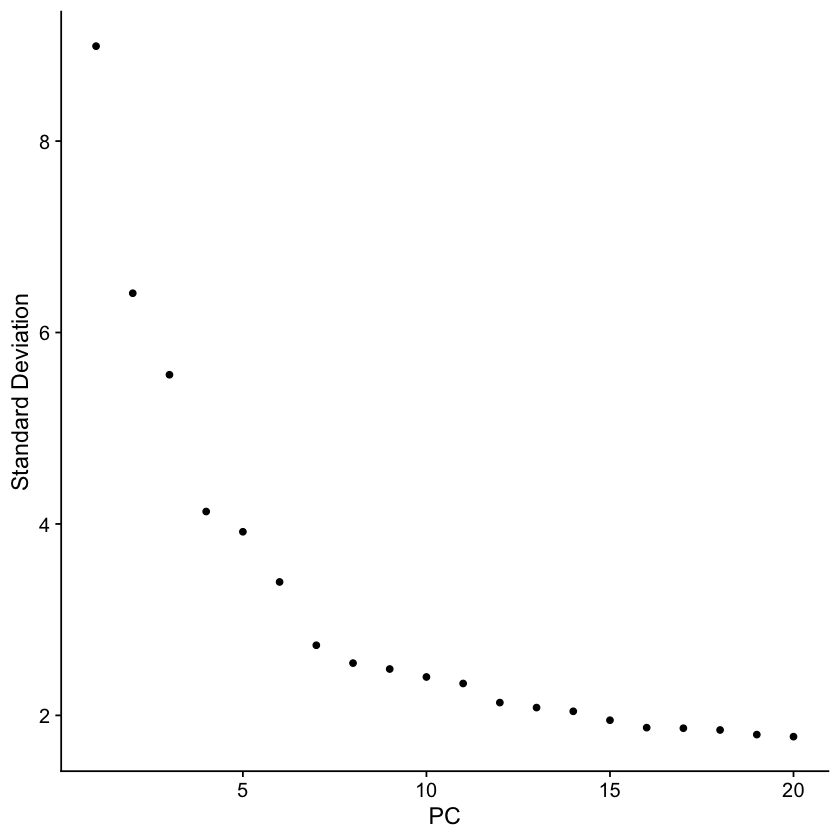

In [57]:
ElbowPlot(pbmc)

关于这个图的解析，官网给的解析是这样的：基于每个元素(PC)解释的方差百分比对主要元素进行排序。在这个例子中，我们可以观察到在 PC9-10周围有一个“肘”，这表明大部分真实信号是在前10个 PC 中捕获的。

我认为可以这样解释，横坐标的PC是你接下来要选择分析的维度数，即多少组基因表达pattern。当选择一组的时候，即所有基因都在一个表达pattern里面（我们从生物学角度看也肯定是不可能的），我们很容易想到，所有细胞都在一个组内，肯定是存在很大差异的，所以方差值（方差=标准差（Standard Deviation）的平方）就会很大。当PC增多，即分组增多后，每个组内的差异也就慢慢变小了，方差值自然也就变小了。再往后，随着选的PC的增多，基本上区分不出来组内的差异了，这个时候方差基本就稳定了下来，此时在选取更大的PC值也就没有更大的意义了，并且还会增加计算压力。因此，个人认为关于PC选取的最合适原则是在拐点右侧3-5个维度即可（本数据拐点在7-8左右，我们选10刚刚好），宽松一点的话，可以设置在拐点右侧10以内。不过最重要的一点还是尽可能地多尝试，选取最适合自己的PC值，这一点也是官网教程所建议的。

## 08 细胞聚类
Seurat 应用了一种基于图表的聚类方法。重要的是，驱动聚类分析的距离度量(基于先前识别的 PC)保持不变。将细胞嵌入到图形结构中-例如 K 最近邻(KNN)图，在具有相似特征表达模式的细胞之间绘制边界，然后将该图划分为高度相互关联的不同簇。

首先基于PCA空间中的欧几里得度量构建一个KNN图，然后基于局部邻域中的共享重叠(Jaccard 相似性)来精确任意两个细胞之间的边缘权重。这个步骤使用FindNeighbors()函数执行，并将先前定义的前10个PC作为输入。

In [58]:
pbmc <- FindNeighbors(pbmc, dims = 1:10)
# Computing nearest neighbor graph
# Computing SNN


Computing nearest neighbor graph

Computing SNN



为了将细胞聚类，我们接下来应用模块化优化技术，如Louvain算法(默认值)或SLM，迭代地将细胞聚类在一起。该步骤通过FindClusters()函数实现，其包含一个解析参数resolution，可以理解为就是分辨率，分辨率数值越高，对细胞分群就越细，分到的群就可能会越多；反之则越少。官网这个3K的细胞集，基本上分辨率会选0.4-1.2.然后还跟我们说，对于较大的数据集，最佳分辨率往往会提高。

In [59]:
pbmc <- FindClusters(pbmc, resolution = 0.5)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1943
Number of edges: 61733

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8813
Number of communities: 11
Elapsed time: 0 seconds


## 09 执行非线性降维（UMAP/tSNE）

Seurat 提供了一些非线性降维技术，如 tSNE 和 UMAP，来可视化和探索这些数据集。这些算法的目标是学习数据集中的底层结构，以便在低维空间中将相似的细胞放在一起。虽然像 tSNE 和 UMAP 这样的二维可视化技术是探索数据集的有价值的工具，但是所有的可视化技术都有局限性，不能完全代表底层数据的复杂性。特别是，这些方法旨在保持数据集中的局部距离(即确保具有非常相似的基因表达谱的细胞共定位) ，但通常不能保持更多的全局关系。（这些是官网翻译过来的原话，关于这一部分没啥好说的，主要作用就是可视化）。



In [60]:
# 官方推荐用UMAP，咱先来UMAP，先降维后可视化
pbmc <- RunUMAP(pbmc, dims = 1:10)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
00:08:30 UMAP embedding parameters a = 0.9922 b = 1.112

00:08:30 Read 1943 rows and found 10 numeric columns

00:08:30 Using Annoy for neighbor search, n_neighbors = 30

00:08:30 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

00:08:30 Writing NN index file to temp file /var/folders/9d/07pjf8p54vb0cjnyp1ql9j2m0000gn/T//RtmpQslIlQ/file5d53173a73ac

00:08:30 Searching Annoy index using 1 thread, search_k = 3000

00:08:31 Annoy recall = 100%

00:08:31 Commencing smooth kNN distance calibrat

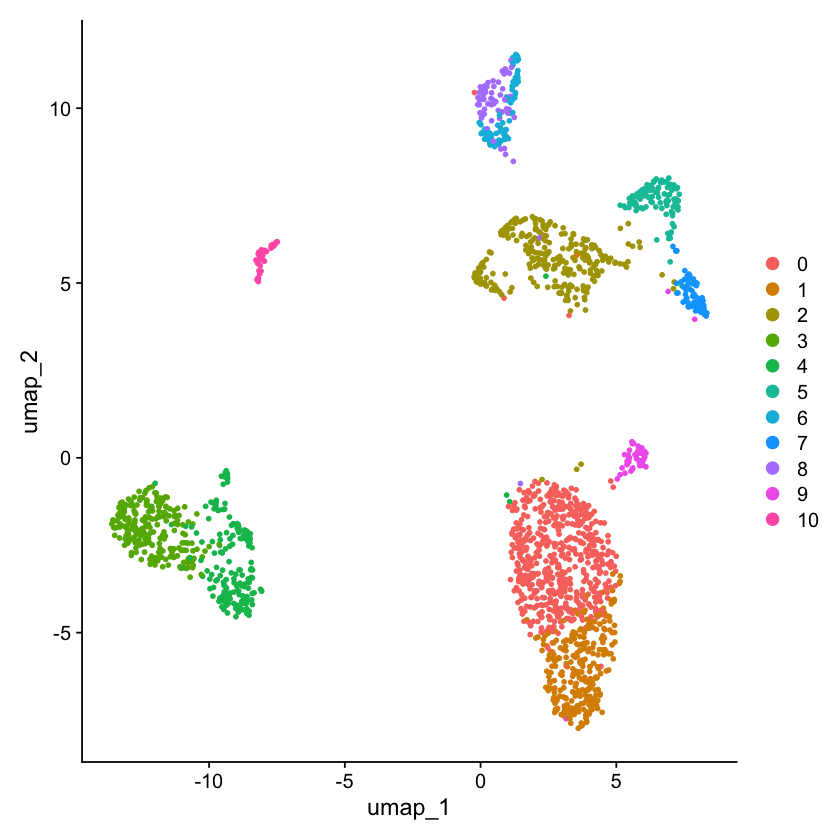

In [61]:
DimPlot(pbmc, reduction = "umap")

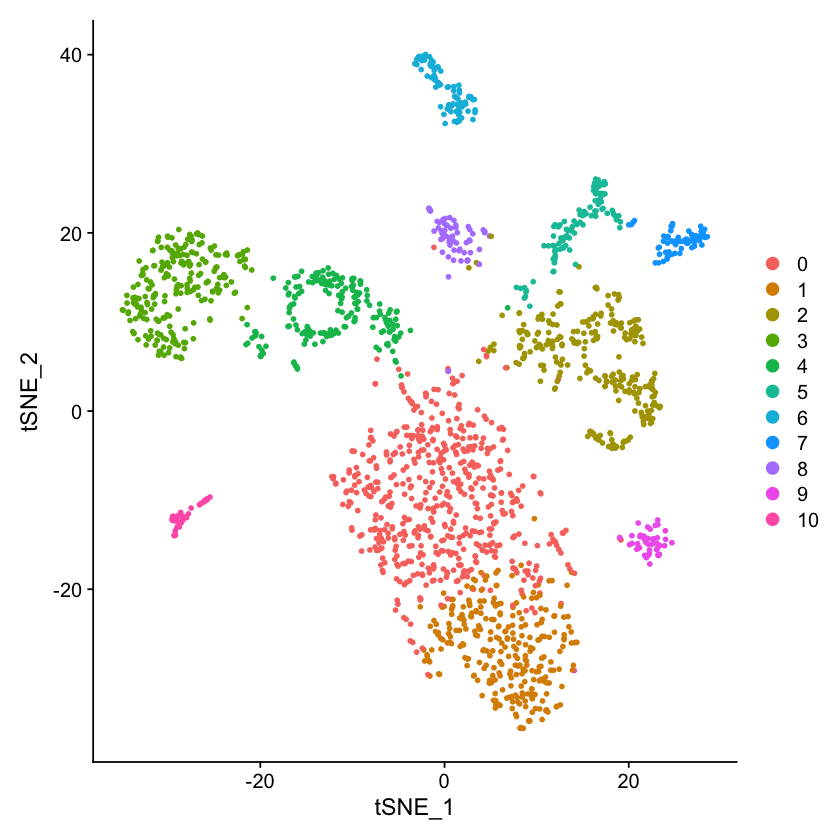

In [62]:
# 咱再试试tSNE
pbmc <- RunTSNE(pbmc, dims = 1:10)
DimPlot(pbmc, reduction = "tsne")

## 10 寻找差异表达基因
Seurat可以通过差异表达(DE)来获取用于定义簇的标记。默认情况下，与所有其他细胞簇相比，它标识单个簇(在 id.1中指定)的正标记和负标记。FindAllMarkers()为所有簇自动完成这个过程，但是您也可以对任意簇之间进行比较，或者是某一簇对其他所有簇进行比较。（官网的话术比较专业，这一步没什么深奥的原理，我们自己写几个就知道了）。

### 计算所有簇的markers
首先第一个，我们就算所有簇的marker基因吧，计算所有簇需要出动FindAllMarkers()，这里官网教程仅设置了一个参数，就是only.pos，这个参数的意思是只保留正标记（positive markers），换句话说也就是只保留相对于其他簇而言，目标簇显著高表达的基因标记。

In [63]:
pbmc.markers <- FindAllMarkers(pbmc, only.pos = TRUE)

Calculating cluster 0

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10



看这个计算过程就知道，每个簇都算一遍，所以簇数多的话，这一步会比较费时间。接下来，就把他们按簇展示一下！

In [64]:
pbmc.markers %>% group_by(cluster)

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
4.643947e-160,2.6060801,0.835,0.213,1.526187e-155,0,GZMA
1.134005e-147,2.4364274,0.813,0.199,3.726793e-143,0,CD2
5.804777e-147,2.9427298,0.712,0.137,1.907682e-142,0,GZMK
1.526772e-137,2.3326881,0.781,0.186,5.017584e-133,0,CD3D
9.734486e-133,1.9948797,0.879,0.292,3.199142e-128,0,IL32
2.222561e-132,2.3861126,0.808,0.259,7.304223e-128,0,CCL5
2.471484e-120,1.9572704,0.851,0.325,8.122284e-116,0,HCST
3.399479e-119,1.0795315,0.996,0.954,1.117205e-114,0,B2M
2.834369e-114,1.0917348,0.982,0.939,9.314870e-110,0,RPS27


In [65]:
head(pbmc.markers %>% group_by(cluster))

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
4.643947e-160,2.606080,0.835,0.213,1.526187e-155,0,GZMA
1.134005e-147,2.436427,0.813,0.199,3.726793e-143,0,CD2
5.804777e-147,2.942730,0.712,0.137,1.907682e-142,0,GZMK
1.526772e-137,2.332688,0.781,0.186,5.017584e-133,0,CD3D
9.734486e-133,1.994880,0.879,0.292,3.199142e-128,0,IL32
2.222561e-132,2.386113,0.808,0.259,7.304223e-128,0,CCL5


In [66]:
tail(pbmc.markers %>% group_by(cluster))

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
0.009886943,1.1425357,0.159,0.061,1,10,COP1
0.009894236,0.8698104,0.341,0.183,1,10,ITGAV
0.009896678,1.8671835,0.114,0.037,1,10,CARM1
0.009905315,0.8067405,0.091,0.026,1,10,CHST15
0.009915880,0.2834110,0.227,0.101,1,10,IFI27
0.009996435,0.9948380,0.227,0.106,1,10,TCEAL9


## 计算特定簇间的markers


In [67]:

# 只计算一下第2簇的markers
cluster2.markers <- FindMarkers(pbmc, ident.1 = 2)


head(cluster2.markers, n = 5)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMP9,1.387603e-115,3.818326,0.974,0.759,4.560218e-111
ACP5,4.334308e-96,3.553028,0.855,0.401,1.424427e-91
SIGLEC15,6.257668e-92,3.505309,0.416,0.036,2.056520e-87
SLC9B2,2.410588e-84,3.962726,0.491,0.075,7.922157e-80
CSTB,4.298511e-80,2.866809,0.885,0.625,1.412663e-75


实验组（ident.1）：聚类编号为 5 和 6 的细胞。

对照组（ident.2）：聚类编号为 0 和 3 的细胞。

In [68]:
cluster5.markers <- FindMarkers(pbmc, ident.1 = c(5,6), ident.2 = c(0, 3))

# 也可以算某几个簇与另外几个簇的差异基因
cluster5.markers <- FindMarkers(pbmc, ident.1 = c(5,6), ident.2 = c(0, 3))


#### FindMarkers中的一些参数
以下面这个代码为例，计算第0簇的markers。logfc.threshold：表示基因在两组细胞间的平均表达量的差异倍数，该参数的默认值设置在0.1，增加该值可以加速运算速度，但可能会错过较弱的信号。通常应用中我使用的是0.25。test.use：对数据进行差异表达测试，可以理解为参数检验，一般笔者采用的方法是wilcox，筛选阈值就是大家常用的p值，也就是0.05。

In [69]:
cluster0.markers <- FindMarkers(pbmc, ident.1 = 0, logfc.threshold = 0.25, test.use = "roc", only.pos = TRUE)

#### 保存markers

In [70]:
# 先把这个markers存入变量，写入变量为了后面好用
All_markers <- pbmc.markers %>% group_by(cluster)

# 保存
write.table(All_markers[All_markers$p_val_adj <= 0.05,], 
            file = "./results/pbmc_all_markers.xls", 
            sep = "\t", 
            col.names = TRUE, 
            row.names = F, 
            quote = F)

实际上，到了这里单细胞Seurat流程的分析基本上走完了，在这里保存RDS是比较合适的，因为里面也存好了计算的差异基因的情况，到时候重新加载RDS文件时，不需要运算即可获取。同时与注释获得完整的细胞类型还有一定的时间要求。所以，我们选择在这里保存第一版分析数据的RDS。



In [72]:
# 保存结果为rds文件
saveRDS(pbmc, file = "./results/pbmc_tutorial.rds")

## 11 基因表达可视化
这一部分是专门添加进来的内容，特意和第10步的内容相区别。关于基因表达可视化，俺有五种方法，任君挑选。至于图的含义，我就不做阐述了，已经挺直观啦！And，后续我们也会出基因表达可视化绘图的内容，可以期待一下！


### 山脊图

Picking joint bandwidth of 0.109

Picking joint bandwidth of 0.0699

Picking joint bandwidth of 0.0598

Picking joint bandwidth of 3.34e-06



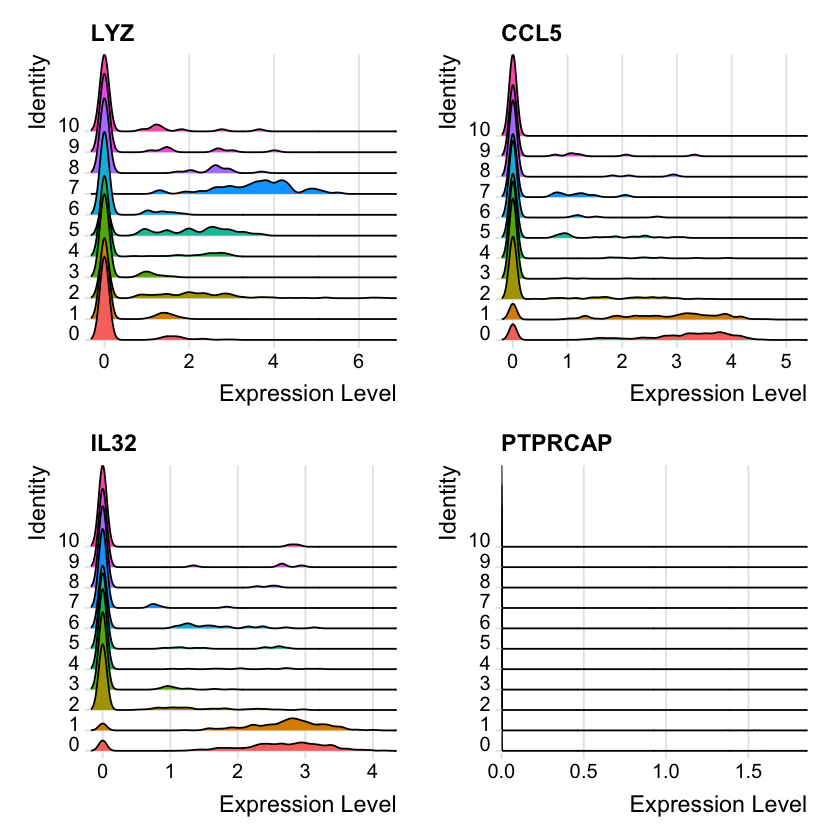

In [73]:
features <- c("LYZ", "CCL5", "IL32", "PTPRCAP")
RidgePlot(pbmc, features = features, ncol = 2)

### 小提琴图

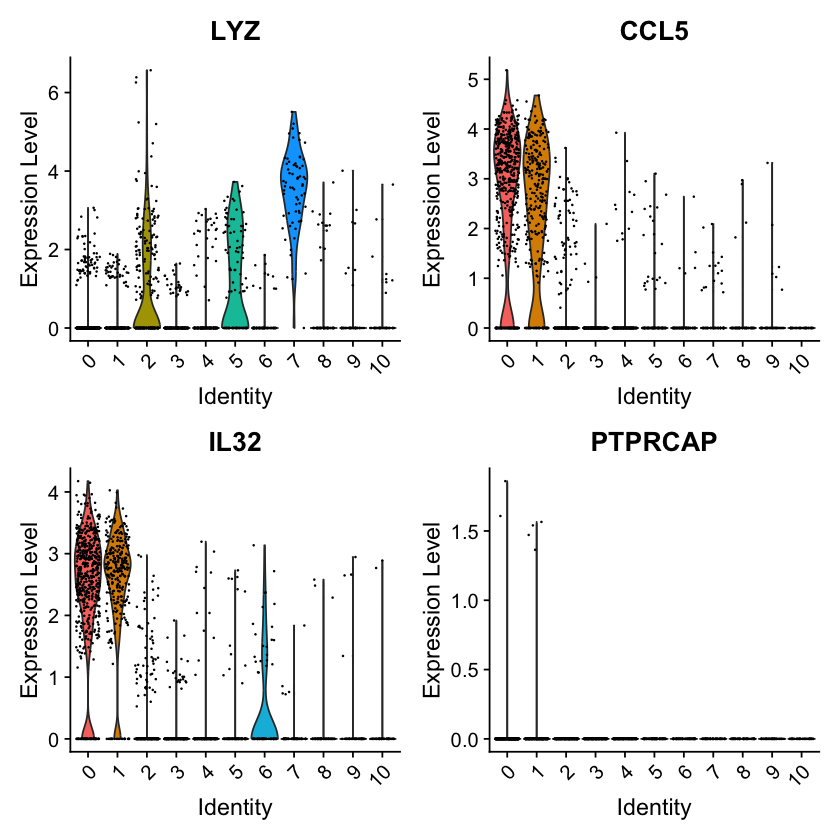

In [74]:
VlnPlot(pbmc, features = features, ncol = 2) 

大家有没有发现山脊图和小提琴图有什么关系嘞？把其中一个图旋转90度试试看哈哈哈哈哈哈哈哈哈哈哈！



### FeaturePlot


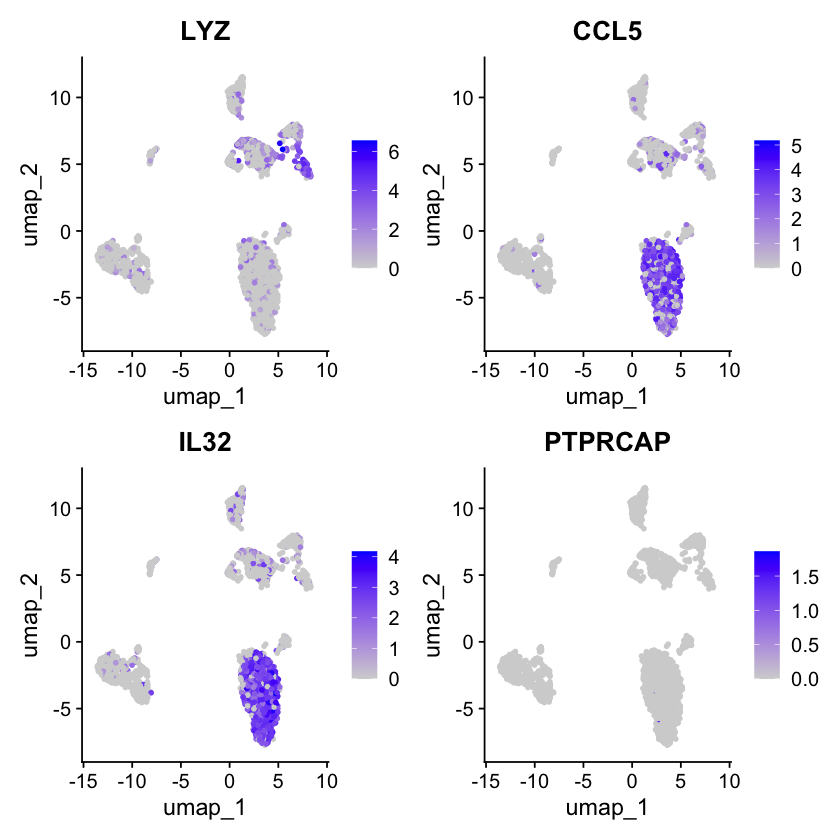

In [75]:
FeaturePlot(pbmc, features = features) 
# 这个图很惭愧，我画的最多，却不知道他中文名应该叫什么

### 点阵图

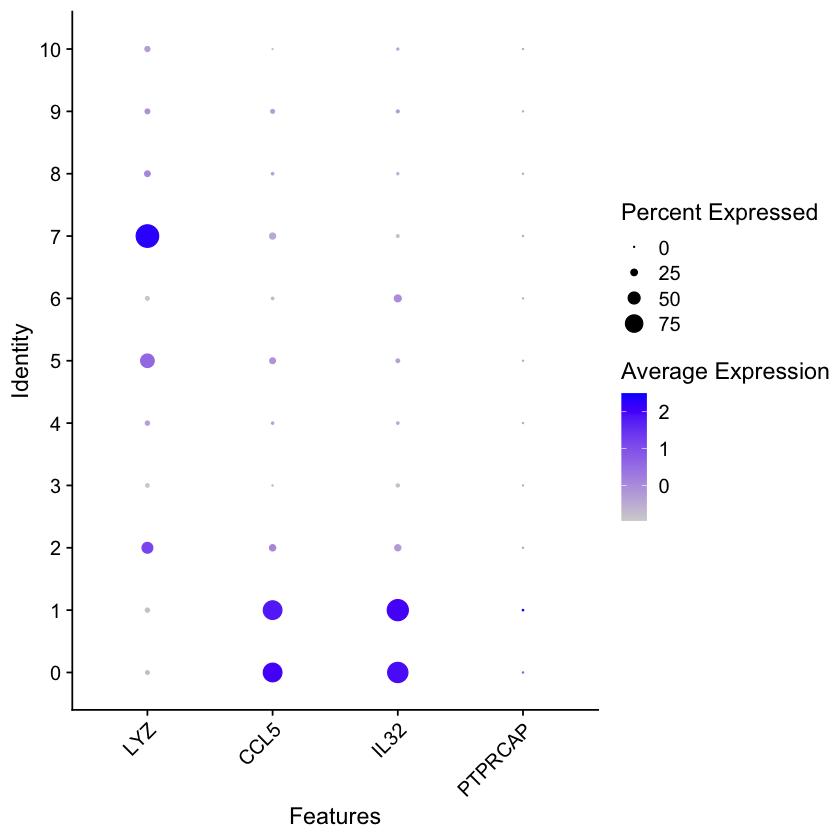

In [76]:
DotPlot(pbmc, features = features) + RotatedAxis() 
# 在文章中标注markers的时候很好用，一个图能放下很多基因。

### 热图


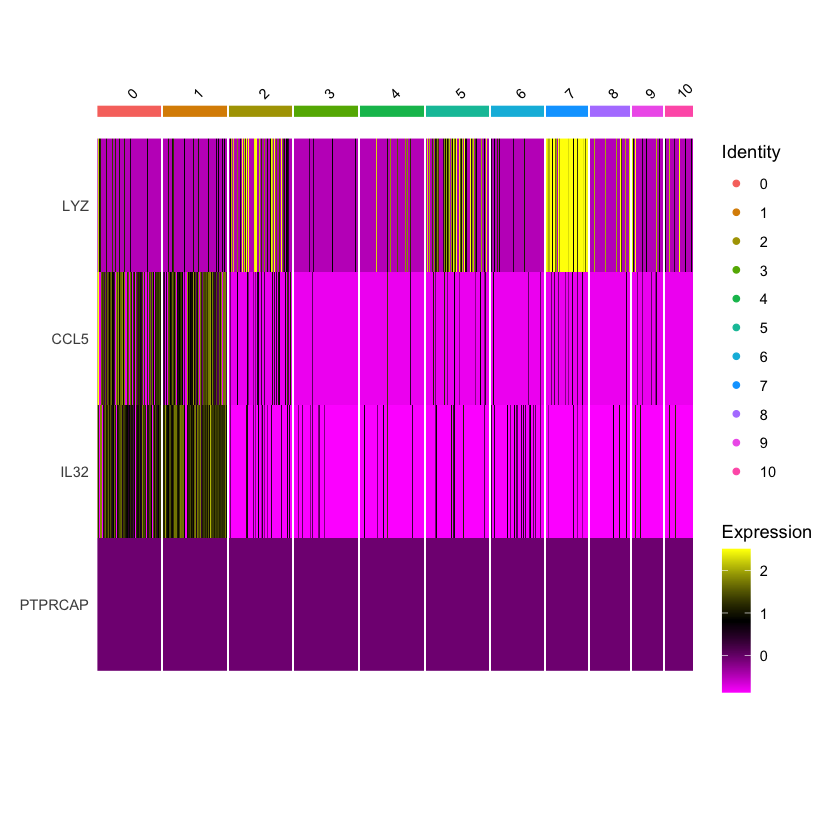

In [77]:
DoHeatmap(subset(pbmc, downsample = 100), features = features, size = 3) 
# 也是一个展示所有注释结果的markers的好形式。

这里记住一点，基因表达量的图是用来显示基因在各簇中的表达情况的，这个为该基因是否可以作为本簇的marker提供了直接的证据来源，如和已有报道相互印证（如XXX细胞特异性表达该基因），则可通过该基因对某一簇细胞进行细胞类型注释。细胞类型注释是一个人工主观的过程（自动注释的应用范围很少，只聚焦在极少数物种中，大多数的细胞类型注释还是依赖人工进行的），这一过程已游离于上述前10步分析之外，所以这就是为什么我在第10步结束的时候保存.rds的原因，不过这里也确实没有细讲如何进行细胞类型注释，咱们后续专门出一期和大家唠唠细胞注释的内容！

## 12 细胞簇命名
假定我们走完上述11步，已经完成了细胞类型注释工作，即知道了每个簇对应的细胞类型。那么现在我们要如何将这些簇更改成对应的细胞名称呢？看我手法：

In [79]:
# 把每个簇对应的新名字写成一个集合
# 这里注意，如果有两个簇注释到的名字一样，
# 要在对应数字位置都写一遍，
# 即一定保证这个集合的元素数和簇的个数是一致的
new.cluster.ids <- c("Naive CD4 T", 
                    "CD14+ Mono", 
                    "Memory CD4 T", 
                    "B", 
                    "CD8 T", 
                    "FCGR3A+ Mono", 
                    "NK", 
                    "DC", 
                    "Platelet",
                    "AND",
                    "CCC")

levels(pbmc)



[1] "0"  "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10"

In [80]:
# 这一步是把pbmc的levels传输给new.cluster.ids作为他的name属性
names(new.cluster.ids) <- levels(pbmc)

In [81]:
levels(pbmc)

[1] "0"  "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10"

In [82]:
new.cluster.ids

0              1              2              3              4 
 "Naive CD4 T"   "CD14+ Mono" "Memory CD4 T"            "B"        "CD8 T" 
             5              6              7              8              9 
"FCGR3A+ Mono"           "NK"           "DC"     "Platelet"          "AND" 
            10 
         "CCC"

In [83]:
names(new.cluster.ids)

[1] "0"  "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10"

In [84]:
# 对pbmc的簇进行重命名
pbmc <- RenameIdents(pbmc, new.cluster.ids)

[1] "Naive CD4 T"  "CD14+ Mono"   "Memory CD4 T" "B"            "CD8 T"       
 [6] "FCGR3A+ Mono" "NK"           "DC"           "Platelet"     "AND"         
[11] "CCC"

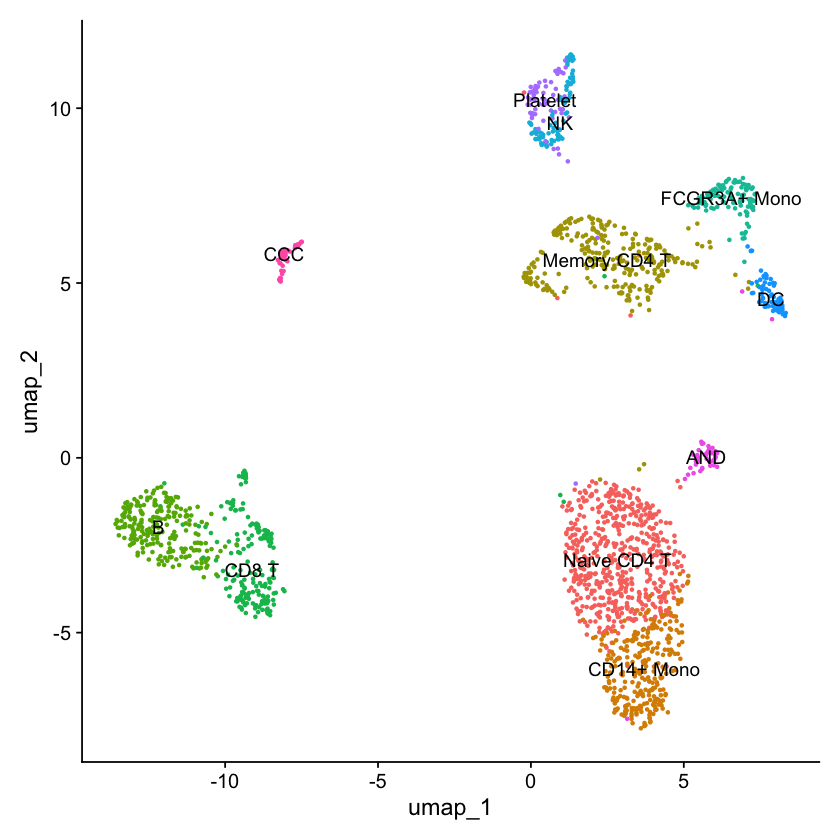

In [85]:
# 可以看到levels中的信息更新成了细胞名称

levels(pbmc)

DimPlot(pbmc, reduction = "umap", label = TRUE, pt.size = 0.5) + NoLegend()

到这里，Seurat的基础分析算全部完成了，这时候我们可以保存一下最完整的信息。


In [87]:
saveRDS(pbmc, file = "./results/pbmc3k_final.rds")